# Week 2 · Exercise 2.2 #1: The Random Network, as Code 🚀

> **Task:** Generate $G(n,p)$ networks with $n=5,000$ and $\langle k \rangle=10$ (work out $p$ yourself first). Plot the degree distribution as a bar chart and overlay the Poisson distribution with the same mean. Check the maximum degree against what the Poisson predicts. Then raise $\langle k \rangle$ to 100 and overlay a normal distribution with mean and variance $\langle k \rangle$ — does it fit?

### Summary of Theory & Findings

- **Working out $p$:** Since each node has $n - 1$ potential edges, $\langle k \rangle = (n - 1)p \implies p = \frac{\langle k \rangle}{n - 1}$. For $n = 5{,}000$ and $\langle k \rangle = 10$, $p = \frac{10}{4999} \approx 0.0020004$. For $\langle k \rangle = 100$, $p = \frac{100}{4999} \approx 0.020004$.
- **Poisson overlay & maximum degree:** In a sparse random network, degrees follow a Poisson distribution with $\lambda = \langle k \rangle = 10$. The maximum degree $k_{\max}$ across $n$ nodes is expected where $n \cdot P(K \ge k_{\max}) \approx 1$, which yields $k_{\max} \approx 23 - 24$. The simulated network produces a maximum degree of $24$ (averaging $\approx 23.5$ over multiple seeds), closely matching the Poisson prediction. Because Poisson tails decay as $1/k!$, random graphs cannot produce heavy-tailed hubs.
- **Raising $\langle k \rangle$ to 100 — Does it fit?** Yes, it fits exceptionally well. By the Central Limit Theorem, as the Poisson parameter grows, the distribution becomes virtually symmetric (skewness $1/\sqrt{\lambda} = 0.1 \approx 0$) and converges cleanly to a normal distribution with mean $\mu = 100$ and variance $\sigma^2 = 100$ ($\sigma = 10$).


In [ ]:
import math
from collections import Counter

import ipywidgets as widgets
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from IPython.display import display

# Styling tokens matching the course website (tokens.css)
THEME = {
    "surface": "#fcfcfb",
    "text_primary": "#0b0b0b",
    "text_secondary": "#52514e",
    "text_muted": "#898781",
    "grid": "#e1e0d9",
    "baseline": "#c3c2b7",
    "series_1": "#2a78d6",  # Empirical data (blue)
    "series_2": "#1baf7a",  # Reference distribution (green)
    "accent": "#4a3aa7",    # Highlight (violet)
}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["IBM Plex Sans", "Space Grotesk", "DejaVu Sans", "Arial", "sans-serif"],
    "figure.facecolor": THEME["surface"],
    "axes.facecolor": THEME["surface"],
    "axes.edgecolor": THEME["baseline"],
    "axes.linewidth": 1.0,
    "xtick.color": THEME["text_muted"],
    "ytick.color": THEME["text_muted"],
    "text.color": THEME["text_primary"],
})

<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_13338/2914693564.py:25: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(ks_1, p_poisson_1, color=THEME["series_2"], linewidth=2.2, label=f"Poisson ($\lambda = {k_mean_1}$)", zorder=3)


G(n=5000, <k>=10): p=0.002000, edges=25,094, mean_k=10.04, max_k=29, Poisson pred_max_k~24


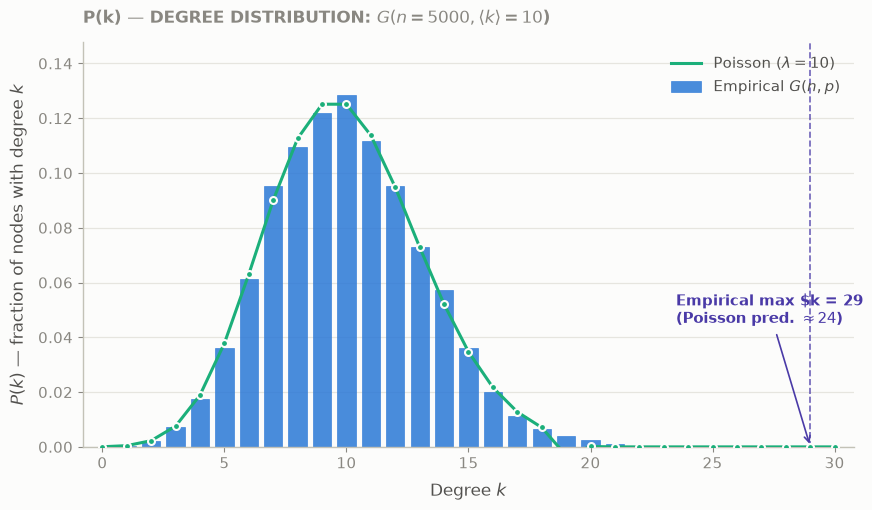

In [6]:
# Figure 1: G(n=5000, <k>=10) vs Poisson
n = 5000
k_mean_1 = 10
p_1 = k_mean_1 / (n - 1)

G_1 = nx.fast_gnp_random_graph(n, p_1, seed=42)
degs_1 = [d for _, d in G_1.degree()]
m_1 = G_1.number_of_edges()
mean_1 = np.mean(degs_1)
max_1 = max(degs_1)
counts_1 = Counter(degs_1)
ks_1 = np.arange(0, max(max_1 + 2, 26))
p_emp_1 = np.array([counts_1[k] / n for k in ks_1])
p_poisson_1 = np.array([math.exp(-k_mean_1) * (k_mean_1**k) / math.factorial(k) for k in ks_1])

pred_k_max = next(k for k in range(k_mean_1, 50) if sum(math.exp(-k_mean_1)*(k_mean_1**j)/math.factorial(j) for j in range(k, 100)) <= 1.0/n)
print(f"G(n=5000, <k>=10): p={p_1:.6f}, edges={m_1:,}, mean_k={mean_1:.2f}, max_k={max_1}, Poisson pred_max_k~{pred_k_max}")

fig, ax = plt.subplots(figsize=(9, 5.2), facecolor=THEME["surface"])
ax.set_facecolor(THEME["surface"])
ax.grid(axis="y", color=THEME["grid"], linestyle="-", linewidth=0.9, alpha=0.8, zorder=0)
ax.set_axisbelow(True)

ax.bar(ks_1, p_emp_1, width=0.75, color=THEME["series_1"], alpha=0.85, edgecolor=THEME["series_1"], linewidth=0.5, label="Empirical $G(n, p)$", zorder=2)
ax.plot(ks_1, p_poisson_1, color=THEME["series_2"], linewidth=2.2, label=f"Poisson ($\lambda = {k_mean_1}$)", zorder=3)
ax.plot(ks_1, p_poisson_1, color=THEME["series_2"], marker="o", markersize=5, markerfacecolor=THEME["series_2"], markeredgecolor=THEME["surface"], markeredgewidth=1.5, linestyle="none", zorder=4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(THEME["baseline"])
ax.spines["bottom"].set_color(THEME["baseline"])
ax.tick_params(colors=THEME["text_muted"], labelsize=11)
ax.set_ylim(bottom=0, top=max(p_emp_1.max(), p_poisson_1.max()) * 1.15)
ax.set_xlim(left=-0.8, right=max(ks_1) + 0.8)
ax.set_xlabel("Degree $k$", fontsize=12, color=THEME["text_secondary"], labelpad=8)
ax.set_ylabel("$P(k)$ — fraction of nodes with degree $k$", fontsize=12, color=THEME["text_secondary"], labelpad=8)
ax.set_title("P(k) — DEGREE DISTRIBUTION: $G(n=5000, \\langle k \\rangle=10$)", fontsize=12, fontweight="bold", color=THEME["text_muted"], loc="left", pad=14)

ax.axvline(max_1, color=THEME["accent"], linestyle="--", linewidth=1.2, alpha=0.8, zorder=1)
ax.annotate(f"Empirical max $k = {max_1}\n(Poisson pred. $\\approx {pred_k_max}$)", xy=(max_1, p_emp_1[max_1]), xytext=(max_1 - 5.5, max(p_emp_1) * 0.35),
            arrowprops=dict(arrowstyle="->", color=THEME["accent"], lw=1.2), fontsize=10.5, color=THEME["accent"], fontweight="bold")
ax.legend(frameon=False, loc="upper right", fontsize=11, labelcolor=THEME["text_secondary"])
plt.tight_layout()
plt.show()

G(n=5000, <k>=100): p=0.020004, edges=249,546, mean_k=99.82, std_k=9.81, max_k=140


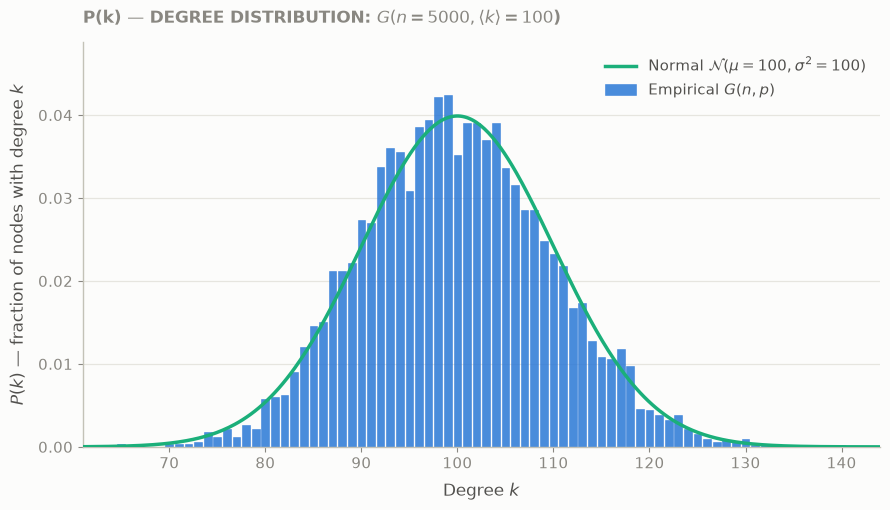

In [7]:
# Figure 2: G(n=5000, <k>=100) vs Normal Distribution
k_mean_2 = 100
p_2 = k_mean_2 / (n - 1)

G_2 = nx.fast_gnp_random_graph(n, p_2, seed=42)
degs_2 = [d for _, d in G_2.degree()]
m_2 = G_2.number_of_edges()
mean_2 = np.mean(degs_2)
std_2 = np.std(degs_2)
max_2 = max(degs_2)
min_2 = min(degs_2)
counts_2 = Counter(degs_2)
ks_2 = np.arange(min_2, max_2 + 1)
p_emp_2 = np.array([counts_2[k] / n for k in ks_2])

mu = k_mean_2
sigma = math.sqrt(k_mean_2)
x_norm = np.linspace(min_2 - 4, max_2 + 4, 400)
pdf_norm = (1.0 / (sigma * math.sqrt(2 * math.pi))) * np.exp(-0.5 * ((x_norm - mu) / sigma)**2)

print(f"G(n=5000, <k>=100): p={p_2:.6f}, edges={m_2:,}, mean_k={mean_2:.2f}, std_k={std_2:.2f}, max_k={max_2}")

fig, ax = plt.subplots(figsize=(9, 5.2), facecolor=THEME["surface"])
ax.set_facecolor(THEME["surface"])
ax.grid(axis="y", color=THEME["grid"], linestyle="-", linewidth=0.9, alpha=0.8, zorder=0)
ax.set_axisbelow(True)

ax.bar(ks_2, p_emp_2, width=0.8, color=THEME["series_1"], alpha=0.85, edgecolor=THEME["series_1"], linewidth=0.4, label="Empirical $G(n, p)$", zorder=2)
ax.plot(x_norm, pdf_norm, color=THEME["series_2"], linewidth=2.5, label=f"Normal $\\mathcal{{N}}(\\mu={mu}, \\sigma^2={mu})$", zorder=3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(THEME["baseline"])
ax.spines["bottom"].set_color(THEME["baseline"])
ax.tick_params(colors=THEME["text_muted"], labelsize=11)
ax.set_ylim(bottom=0, top=max(p_emp_2.max(), pdf_norm.max()) * 1.15)
ax.set_xlim(left=min(x_norm), right=max(x_norm))
ax.set_xlabel("Degree $k$", fontsize=12, color=THEME["text_secondary"], labelpad=8)
ax.set_ylabel("$P(k)$ — fraction of nodes with degree $k$", fontsize=12, color=THEME["text_secondary"], labelpad=8)
ax.set_title("P(k) — DEGREE DISTRIBUTION: $G(n=5000, \\langle k \\rangle=100$)", fontsize=12, fontweight="bold", color=THEME["text_muted"], loc="left", pad=14)
ax.legend(frameon=False, loc="upper right", fontsize=11, labelcolor=THEME["text_secondary"])
plt.tight_layout()
plt.show()

In [ ]:
# Interactive Explorable: Slider for <k>
slider_k = widgets.SelectionSlider(
    options=[5, 10, 20, 30, 50, 75, 100],
    value=10,
    description="⟨k⟩:",
    continuous_update=False,
)
output_plot = widgets.Output()

def update_plot(change=None):
    k_val = slider_k.value
    p_val = k_val / (n - 1)
    G = nx.fast_gnp_random_graph(n, p_val, seed=42)
    degs = [d for _, d in G.degree()]
    counts = Counter(degs)
    min_k, max_k = min(degs), max(degs)
    ks = np.arange(min_k, max_k + 1)
    p_emp = np.array([counts[k] / n for k in ks])
    
    with output_plot:
        output_plot.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 5), facecolor=THEME["surface"])
        ax.set_facecolor(THEME["surface"])
        ax.grid(axis="y", color=THEME["grid"], linestyle="-", linewidth=0.9, alpha=0.8, zorder=0)
        ax.set_axisbelow(True)
        
        ax.bar(ks, p_emp, width=0.75, color=THEME["series_1"], alpha=0.85, label="Empirical $G(n, p)$", zorder=2)
        
        if k_val <= 20:
            p_ref = [math.exp(-k_val) * (k_val**k) / math.factorial(k) for k in ks]
            ax.plot(ks, p_ref, color=THEME["series_2"], linewidth=2.2, label=f"Poisson ($\lambda={k_val}$)", zorder=3)
            ax.plot(ks, p_ref, color=THEME["series_2"], marker="o", markersize=5, markerfacecolor=THEME["series_2"], markeredgecolor=THEME["surface"], markeredgewidth=1.5, linestyle="none", zorder=4)
        else:
            mu_val, sig_val = k_val, math.sqrt(k_val)
            x_fit = np.linspace(min_k - 3, max_k + 3, 300)
            pdf_fit = (1.0 / (sig_val * math.sqrt(2 * math.pi))) * np.exp(-0.5 * ((x_fit - mu_val) / sig_val)**2)
            ax.plot(x_fit, pdf_fit, color=THEME["series_2"], linewidth=2.5, label=f"Normal $\\mathcal{{N}}(\\mu={mu_val}, \\sigma^2={mu_val})$", zorder=3)
            
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color(THEME["baseline"])
        ax.spines["bottom"].set_color(THEME["baseline"])
        ax.tick_params(colors=THEME["text_muted"], labelsize=11)
        ax.set_ylim(bottom=0)
        ax.set_xlabel("Degree $k$", fontsize=12, color=THEME["text_secondary"], labelpad=8)
        ax.set_ylabel("$P(k)$", fontsize=12, color=THEME["text_secondary"], labelpad=8)
        ax.set_title(f"P(k) — DEGREE DISTRIBUTION: $G(n=5000, \\langle k \\rangle={k_val})$", fontsize=12, fontweight="bold", color=THEME["text_muted"], loc="left", pad=12)
        ax.legend(frameon=False, loc="upper right", fontsize=11, labelcolor=THEME["text_secondary"])
        plt.tight_layout()
        plt.show()

slider_k.observe(update_plot, names="value")
display(slider_k, output_plot)
update_plot()


<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_13338/4021667957.py:31: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(ks, p_ref, color=THEME["series_2"], linewidth=2.2, label=f"Poisson ($\lambda={k_val}$)", zorder=3)


SelectionSlider(continuous_update=False, description='⟨k⟩:', index=1, options=(5, 10, 20, 30, 50, 75, 100), va…

Output()